# Project 3: Prediction

In [1]:
# FIXME: Enter your group name here
GROUP = "X"
# uabcdef
# ughijkl
# umnopqr

## 3.0 Preparation

Ensure that you run this notebook in your project environment created for the previous project. *On Windows: ensure that you are using WSL!*

Import the necessary Python modules. We will re-use the FeniCS interface from the previous project. For that to work, you need to place this Jupyter notebook in the `project` directory (the directory containing `phys.ipynb`).

In [2]:
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random
import tensorflow as tf
import import_ipynb

from phys import FenicsInterface
from fem.base import grids

I0000 00:00:1784786824.770934 1828221 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784786824.956289 1828221 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784786828.260472 1828221 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


dolfinx 0.10.0


<string>:18: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


## 3.1 Create a data-generating function

The dataset should consist of multiple samples of features, some of which are used as input and output for our machine-learning problem.
Based on the subsequent tasks in this notebooks, the input features must be varied.

We will use the elastoplastic finite-element cube from Project 1 and 2 as data-generating function. As in Project 2, apply just a displacement-controlled loading and no unloading and remember to assemble the histories into single numpy arrays. Compute the same derived values as in Project 2. The data-generating functions should return a dictionary of numpy arrays for the each sample of varied input parameters.

In [3]:
# Do not change this cell!
#   This function is a useful helper to apply grid encoding to the frame data. The lines
#   using it later are already prepared for you. You do not need to use it anywhere else
#   in the notebook or modify this function.
def apply_grid_encoding(frame, grid_shape):
    """Grid encode the frame data."""
    Xi = frame["Xi"]
    origin = np.min(Xi, axis=0)
    geometry = tuple(np.max(Xi, axis=0) - np.min(Xi, axis=0))
    grid_coords = grids.generate_grid(geometry, grid_shape) + origin
    reduced_frame = {
        k: v
        for k, v in frame.items()
        if "fenics" not in k and "bc_" not in k and isinstance(v, np.ndarray)
    }
    del reduced_frame["Pi"]
    _, _, grid_encoded = grids.grid_encode(grid_coords, grid_shape, Xi, reduced_frame)
    return grid_encoded

Use the provided function and signature for `solve_fem(...)` and complete the physics-based finite-element simulation code within.

The result dictionary is currently missing Young's (elastic) modulus `E` and the tensile yield limit `sig0`.
In addition, extract the deformation imposed on the elastoplastic cube at the boundaries and store it in `U_boundary`. The tensor `U_boundary` should have only values other than zero in the 0 and -1 indices of the spatial axes (27, 27).

Add all three values to the result dictionaries as they will be needed to prepare the data for the prediction. 

In [4]:
def solve_fem(E=7e10, u0=1e-3, nu=0.3, rho=0.0, sig0=2.50e8, Et=1e-9):
    """Solve the elastoplastic cube problem using the FenicsInterface.

    Args:
        E (float, optional): Young's (elastic) modulus. Defaults to 7e10.
        u0 (float, optional): Maximum displacement at the left and right edges of the cube. Defaults to 1e-3.
        nu (float, optional): Poisson's ratio. Defaults to 0.3.
        rho (float, optional): Density of the material. Defaults to 0.0.
        sig0 (float, optional): Tensile yield limit. Defaults to 2.50e8.
        Et (float, optional): Tangent modulus for kinematic hardening. Defaults to 1e-9.

    Returns:
        dict: A dictionary containing the results of the simulation as feature tensors.
    """

    # FIXME Run the simulations using the FenicsInterface

    fi = FenicsInterface()
    fi.VERBOSITY = 2
    fi.DEBUG = False
    #fi.plot = False

    # Define geometry, material properties, and boundary conditions
    #   Keep the geometry as a 2D square with length 1.0 in both x and y directions
    geometry = [1.0, 1.0]  # Length in x and y directions

    # Define material properties
    #    Bilinear elastoplastic material with kinematic hardening
    material = [E, nu, rho, sig0, Et]    

    # Define properties
    #    Thickness of the material is 1.0, which is a common assumption for 2D problems
    thickness = 1.0  # Thickness of the material
    properties = [thickness]

    # Define boundary conditions
    #    At the left and right edges of the cube, we apply linear bending displacement.
    #    The dislacement are defined as a function of the y coordinate.
    #    The maximum displacement is defined as u0 as an input to the function.

    def lin_pos_y(node, max_val, **kwargs):
        return max_val * 2.0 * (node[2] - geometry[1] / 2.0) / geometry[1]
    
    lin_pos_y.cpp_code = "max_val * (x[1] - geometry1 / 2.0) * (2.0 / geometry1)"

    def lin_neg_y(node, max_val, **kwargs):
        return -lin_pos_y(node, max_val)

    lin_neg_y.cpp_code = "- max_val * (x[1] - geometry1 / 2.0) * (2.0 / geometry1)"

    bc_u1 = {
        "xn": [lin_pos_y, None],  # left edge
        "xp": [lin_neg_y, None],  # right edge
        "yn": [],
        "yp": [],
        "all": [],
        "pointwise": [],
    }
    fi.bc_fun_kwargs = {"max_val": u0, "unit_disp": 0.0, "coords":None}

    # Finite element settings
    grid_shape = [27, 27]  # Number of elements in x and y directions
    fi.interpolation_order = 2  # element interpolation order (1: linear, 2: quadratic)
    fi.min_increment = 5  # Minimum number of time increments
    fi.max_iteration = 100  # Maximum number of iterations
    fi.tol = 1e-10  # Tolerance for convergence
    fi.regularization = 1.0  # Regularization parameter

    fe_histories = []  # List to store the finite element histories

    # FIXME Load the geometry
    print("Loading geometry...")  
    
    fe_history_load = fi.adaptive_time_increments(
        fi.elastoplastic_cube, geometry, material, properties, grid_shape, bc_u1
    )   
    
    fe_histories += [fe_history_load]

    # Check if the results are numerically stable and correct
    assert (
        np.max(fi.extract_stress_values(fe_histories[0][-1]["Si"], stress_type="mises"))
        > 0.0
    )
    assert np.max(
        fi.extract_stress_values(fe_histories[0][-1]["Si"], stress_type="mises")
    ) <= sig0 * (1.0 + 1e-4)

    # Assemble the results into a dictionary containing the feature tensors
    #    The tensors should be of the following dimensions:
    #    T: Number of time frames (varies with the number of increments)
    #    X: Number of grid points in x direction (27 in this case)
    #    Y: Number of grid points in y direction (27 in this case)
    #    F: Number of features (2 for displacement and force, 6 for stress,
    #       1 for Von Mises stress)

    def apply_grid_encoding(frame, grid_shape):
        Xi = frame["Xi"]
        origin = np.min(Xi, axis=0)
        geom = tuple(np.max(Xi, axis=0) - np.min(Xi, axis=0))
        grid_coords = grids.generate_grid(geom, grid_shape) + origin
        reduced = {
            k: v
            for k, v in frame.items()
            if "fenics" not in k and "bc_" not in k and isinstance(v, np.ndarray)
        }
        reduced.pop("Pi", None)
        _, _, enc = grids.grid_encode(grid_coords, grid_shape, Xi, reduced)
        return enc
        
    frames = [
        apply_grid_encoding(f, grid_shape)
        for h in fe_histories
        for f in h.values()
        if f
    ]
    frames = [
        {k: np.zeros_like(v) for k, v in frames[-1].items()}
    ] + frames  # add initial zero frame for initial state
    
    U = np.stack([f["Ui"] for f in frames], axis=0)
    F = np.stack([f["Fi"] for f in frames], axis=0)
    S = np.stack([f["Si"] for f in frames], axis=0)
    Mises = fi.extract_stress_values(S, stress_type="mises")
    Mises = Mises[..., np.newaxis]  # Add a new axis for compatibility
    

    # FIXME Compute U boundary from a copy of U
    U_boundary = np.zeros_like(U)
    U_boundary[:, 0, :, :] = U[:, 0, :, :]
    U_boundary[:, -1, :, :] = U[:, -1, :, :]    

    results = {
        # FIXME Add E, sig0 and U_boundary
        "E": np.array(E),
        "sig0": np.array(sig0),
        "U_boundary": U_boundary,
        "U": U,  # Displacement tensor of shape (T, X, Y, 2)
        "F": F,  # Force tensor of shape (T, X, Y, 2)
        "S": S,  # Stress tensor of shape (T, X, Y, 6)
        "Mises": Mises,  # Von Mises stress tensor of shape (T, X, Y, 1)
    }

    # FIXME Compute non-local and non-directional features from the results.
    #  Compute the magnitudes of the displacement and force vectors at each grid point
    #  for each time frame and store them in the results dictionary.
    
    u = np.linalg.norm(U, axis=-1)  # Magnitude of displacement tensor of shape (T, X, Y, 1)
    f = np.linalg.norm(F, axis=-1)  # Magnitude of force tensor of shape (T, X, Y, 1)
    results["max_u"] = np.max(u, axis=(1, 2))  # Max displacement magnitude tensor of shape (T, 1)
    results["min_u"] = np.min(u, axis=(1, 2))  # Min displacement magnitude tensor of shape (T, 1)
    results["max_f"] = np.max(f, axis=(1, 2))  # Max force magnitude tensor of shape (T, 1)
    results["min_f"] = np.min(f, axis=(1, 2))  # Min force magnitude tensor of shape (T, 1)
    results["max_mises"] = np.max(Mises, axis=(1, 2, 3))  # Max Von Mises stress tensor of shape (T, 1)
    results["min_mises"] = np.min(Mises, axis=(1, 2, 3))  # Min Von Mises stress tensor of shape (T, 1)

    return results

## 3.2 Generate data

Run the data-generating function a few times. Vary the input features `E`, `sig0` and `u0` in the intervals given in the cell directly below. Select a suitable randomization method (Use the `numpy` or `random` modules). 

Collect the results of each simulation (samples) in a suitable data structure. Finally, store that data structure using `np.save`.

After you are happy with the generated data, you should increase the number of samples to `num_samples = 100` or higher. Use the `RECREATE` flag to only execute the time-intensive data generation when needed. 

In [5]:
RECREATE = False  # Set to True to re-run the simulation

results_file = Path(f"RESULTS/samples_group{GROUP}.npy")
results_file.parent.mkdir(parents=True, exist_ok=True)

# Define dataset and variable ranges
num_samples = 100
E_min, E_max = 6e10, 8e10 
u0_min, u0_max = 1e-3, 4e-3 
sig0_min, sig0_max = 2.50e8, 2.75e8

In [6]:
# Check if the results file exists and if we need to recreate it
if RECREATE or not results_file.exists():
    # Run multiple iterations to generate a first dataset
    samples_list = []
    for _ in tqdm(range(num_samples), desc="Data Generation"):
        # FIXME Use a randomization function within the boundaries
        # Call the solve_fem function with the random values
        # Store the result in a list
        E_rand = random.randint(E_min, E_max)
        u0_rand = random.uniform(u0_min, u0_max)
        sig0_rand = random.uniform(sig0_min, sig0_max)

        results = solve_fem(
            E = E_rand,
            u0 = u0_rand,
            sig0 = sig0_rand
        )
        
        samples_list.append(results)
        
    # FIXME Save the samples in a npy file
    np.save(results_file, samples_list)
    print(results_file)
else:
    # Load results results
    samples_list = np.load(results_file, allow_pickle=True)

In [7]:
# Check the loaded/generated data
for key, value in samples_list[0].items():
    print(f"{key}: {value.shape if isinstance(value, np.ndarray) else value}")

assert "E" in samples_list[0]
assert "sig0" in samples_list[0]
assert "U_boundary" in samples_list[0].keys()
assert not np.any(samples_list[0]["U_boundary"][:, 1:-1, 1:-1, :])

E: ()
sig0: ()
U_boundary: (6, 27, 27, 2)
U: (6, 27, 27, 2)
F: (6, 27, 27, 2)
S: (6, 27, 27, 6)
Mises: (6, 27, 27, 1)
max_u: (6,)
min_u: (6,)
max_f: (6,)
min_f: (6,)
max_mises: (6,)
min_mises: (6,)


# 3.3 Prediction of dense neural networks

Predict the outputs `max_f` and `max_mises` from the inputs `max_u`, `E`, and `sig0`.


**(a) Assemble the input and output features and tensors.**

For the prediction, the inputs and target features need to be assembled as tensors (`np.ndarrays`) of multiple samples. The first axis of these tensors corresponds to the sample axis.
Example for `max_u_tensor` (N=100, T=6, F=1). You may need to expand scalar features to the sequence shape.



In [8]:
# Create empty list to store the data
#   Note: there are faster ways to do this, but we keep the code simple for clarity
max_u_list = []
E_list = []
sig0_list = []
max_f_list = []
max_mises_list = []

# Iterate over the samples and extract the relevant data
for sample in samples_list:
    
    # FIXME Extract the relevant data from the sample
    max_u = sample["max_u"][:, np.newaxis]
    E = sample["E"]
    sig0 = sample["sig0"]
    max_f = sample["max_f"][:, np.newaxis]
    max_mises = sample["max_mises"][:, np.newaxis]
    
    # FIXME Expand the scalars to match the structural shapes of the other features
    
    E = np.ones_like(max_u) * E
    sig0 = np.ones_like(max_u) * sig0
    
    # Store the data
    max_u_list.append(max_u)
    E_list.append(E)
    sig0_list.append(sig0)
    max_f_list.append(max_f)
    max_mises_list.append(max_mises)

print(max_u.shape)
print(E.shape)

(6, 1)
(6, 1)


Assemble the input and output tensors `X` and `Y` by concatenating the feature tensors along the last feature axis F (`np.concatenate`). 

In [9]:
# FIXME Convert features to numpy arrays of compatible shapes
max_u_tensor = np.asarray(max_u_list)  # shape: (N, 6, 1)
E_tensor = np.asarray(E_list)  # shape: (N, 6, 1)
sig0_tensor = np.asarray(sig0_list)  # shape: (N, 6, 1)
max_f_tensor = np.asarray(max_f_list)  # shape: (N, 6, 1)
max_mises_tensor = np.asarray(max_mises_list)  # shape: (N, 6, 1)

print(max_u_tensor.shape)
print(E_tensor.shape)
print(sig0_tensor.shape)
print(max_f_tensor.shape)
print(max_mises_tensor.shape)

# FIXME Assemble the input features
X = np.concatenate([max_u_tensor, E_tensor, sig0_tensor], axis=-1)

# FIXME Assemble the target features
Y = np.concatenate([max_f_tensor, max_mises_tensor], axis=-1)

print(X.shape)
print(Y.shape)

(100, 6, 1)
(100, 6, 1)
(100, 6, 1)
(100, 6, 1)
(100, 6, 1)
(100, 6, 3)
(100, 6, 2)


**(b) Split the dataset**

Perform a suitable dataset split for the size of the dataset you generated.
The sklearn function `train_test_split` may help you.

In [10]:
# FIXME Train-test split (keep temporal structure)
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

**(c) Normalize the input and output data**

 Use the sklearn `StandardScaler` to scale inputs `X` and outputs `Y` to a standard deviation of +-1. 
 Ensure that the relative variance across the temporal axis T=6 (and later spatial axes X=Y=27) remain unchanged.
 Remember to restore the structural axes (T, X, Y) afterwards

 (Tip: use `np.reshape` to collapse all non-feature axes into the samples axis and restore the shape afterwards).

In [11]:
# FIXME Standardize and reshape the values
# Assume the structural shape of the input and output dataset: (N, T, F)
N_X_train, T_X_train, F_X_train = X_train.shape
N_X_test, T_X_test, F_X_test = X_test.shape
N_Y_train, T_Y_train, F_Y_train = Y_train.shape
N_Y_test, T_Y_test, F_Y_test = Y_test.shape

# Flatten non-feature axes into a single dimension: (N * T, F)
X_train_flat = X_train.reshape(-1, F_X_train)
X_test_flat = X_test.reshape(-1, F_X_test)
Y_train_flat = Y_train.reshape(-1, F_Y_train)
Y_test_flat = Y_test.reshape(-1, F_Y_test)

# Fit the scaler on the data and transform it
X_scaler = StandardScaler()
Y_scaler = StandardScaler()

X_train_scaled_flat = X_scaler.fit_transform(X_train_flat)
X_test_scaled_flat = X_scaler.transform(X_test_flat)
Y_train_scaled_flat = Y_scaler.fit_transform(Y_train_flat)
Y_test_scaled_flat = Y_scaler.transform(Y_test_flat)

# Restore original structural shape: (N, T, F)
X_train0 = X_train_scaled_flat.reshape(N_X_train, T_X_train, F_X_train)
X_test0 = X_test_scaled_flat.reshape(N_X_test, T_X_test, F_X_test)
Y_train0 = Y_train_scaled_flat.reshape(N_Y_train, T_Y_train, F_Y_train)
Y_test0 = Y_test_scaled_flat.reshape(N_Y_test, T_Y_test, F_Y_test)

**(d) Model development**

Develop a neural network model. Either use `tf.keras.Model` or `tf.keras.Sequential`.

To define the architecture in the model, tensorflow's `layers` module may help you (e.g., `layers.Dense`, `layers.Input`).
Chose reasonable activation functions for your machine-learning problem.
You will need to operate on individual time steps. For dense layers to be applied to individual frames of a time step, wrap them in a `layers.TimeDistributed` layer.

Compile the model and select an apropriate optimzer, loss, and metric function.

In [12]:
# FIXME: Define a time-distributed dense neural network
from tensorflow.keras import layers, models

# Extract shape from normalized traning dataset: (N, T, F)
_, time_steps, n_features_in = X_train0.shape
_, _, n_features_out = Y_train0.shape

# Define model acrchitecture
model = models.Sequential([
    # Input layer expecting (time_steps, n_features)
    layers.Input(shape=(time_steps, n_features_in)),

    # Hidden layers wrapped in TimeDistributed
    layers.TimeDistributed(layers.Dense(128, activation="tanh")),
    layers.TimeDistributed(layers.Dense(128, activation="tanh")),
    layers.TimeDistributed(layers.Dense(128, activation="tanh")),
    layers.TimeDistributed(layers.Dense(56, activation="tanh")),

    # Output layer: linear activation for regression
    layers.TimeDistributed(layers.Dense(n_features_out, activation="linear"))
])

# Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",        # Mean Squared Error for regressing
    metrics=["mae"]    # Mean Absolute Error for tracking
)


W0000 00:00:1784786835.077842 1828221 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [13]:
# Print summary to verify output shapes match (None, T, F)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 6, 128)         │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 6, 128)         │        16,512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 6, 128)         │        16,512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 6, 56)          │         7,224 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 6, 2)           │           114 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,874 (159.66 KB)

 Trainable params: 40,874 (159.66 KB)

 Non-trainable params: 0 (0.00 B)

**(e) Train the Model**

Train the model until you achieve convergence and generalization. Remember to validate your training performance against a validation dataset.

In the process, you may need to change your model hyperparameters (number of layers, number of units per layer, activation functions, learning rate, batch size, ...).

Do not evaluate your test set yet!

In [14]:
# FIXME: Train the model
history = model.fit(
    X_train0,
    Y_train0,
    validation_split=0.2,
    epochs = 500,
    batch_size = 4,
    verbose = 1
)

Epoch 1/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.2791 - mae: 0.3738 - val_loss: 0.0700 - val_mae: 0.1944
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0530 - mae: 0.1807 - val_loss: 0.0546 - val_mae: 0.1751
Epoch 3/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0251 - mae: 0.1226 - val_loss: 0.0198 - val_mae: 0.1056
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0175 - mae: 0.1072 - val_loss: 0.0140 - val_mae: 0.0926
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0127 - mae: 0.0920 - val_loss: 0.0138 - val_mae: 0.0961
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0106 - mae: 0.0847 - val_loss: 0.0110 - val_mae: 0.0862
Epoch 7/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0089 - mae: 0.0765 - val_loss: 0.0085 - val_mae: 0.0763
Epoch 8/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0080 - mae: 0.0735 - val_loss: 0.0078 - val_mae: 0.0717
Epoch 9/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

**(f) Plot the training and validation performance**

Plot your loss and metrics using `subplot` from `matplotlib`

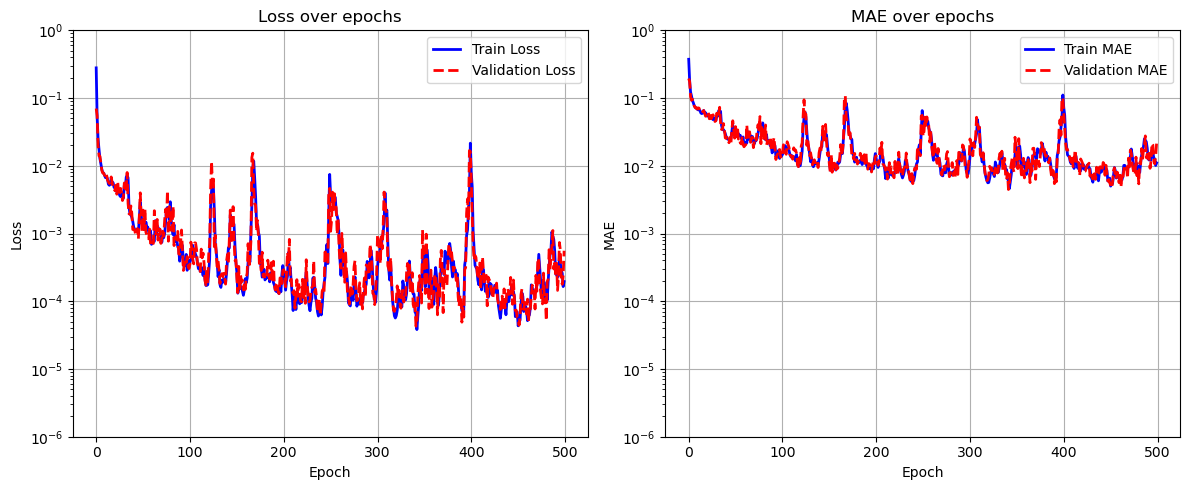

In [15]:
# FIXME Plot training & validation loss
plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)

if "loss" in history.history:
    plt.plot(history.history["loss"], label="Train Loss", color="blue", linewidth=2)
    plt.plot(history.history["val_loss"], label="Validation Loss", color="red", linestyle="--", linewidth=2)

plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.yscale("log") # Log scale makes convergence and small difference clear
plt.ylim(1e-6, 1.0)
plt.grid(True)

# metric
if "mae" in history.history:
    plt.subplot(1, 2, 2)

    plt.plot(history.history["mae"], label="Train MAE", color="blue", linewidth=2)
    plt.plot(history.history["val_mae"], label="Validation MAE", color="red", linestyle="--", linewidth=2)
    
    plt.title('MAE over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.yscale("log") # Log scale makes convergence and small difference clear
    plt.ylim(1e-6, 1.0)
    plt.grid(True)

plt.tight_layout()
plt.show()

**(g) Postprocess the outputs on the test set**

Retransform the predicted data to it's original scale using `inverse_transform`. Also, make sure to use `reshape` so that the final shape is correct.

In [16]:
# Evaluate the model
# Predict sclaed outputs on the test set
# Output shape: (N, T, F)
Y_pred0 = model.predict(X_test0)

# Store original shape
Y_pred0_shape = Y_pred0.shape

# Reshape to 2D for inverse transformation: (N * T, F)
Y_pred0_flat = Y_pred0.reshape(-1, Y_pred0_shape[-1])
Y_test0_flat = Y_test0.reshape(-1, F_Y_test)

# Inverse transform  back to original physical scale
Y_pred0_ori_flat = Y_scaler.inverse_transform(Y_pred0_flat)
Y_test0_ori_flat = Y_scaler.inverse_transform(Y_test0_flat)

# Reshape back to the original 3D sequence shape: (N, T, F)
Y_pred = Y_pred0_ori_flat.reshape(Y_pred0_shape)
Y_true = Y_test0_ori_flat.reshape(N_Y_test, T_Y_test, F_Y_test)

print("Y_pred0:", Y_pred0.shape)
print("Y_pred:", Y_pred.shape)
print("Y_true:", Y_true.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Y_pred0: (20, 6, 2)
Y_pred: (20, 6, 2)
Y_true: (20, 6, 2)


**(h) Evaluate the model predictions on the test set**

Evaluate max_f and max_mises individually using `mean_absolute_error`, `mean_squared_error`, `r2_score`.

In [17]:
# Reshape the true and predicted array
Y_true_flat = Y_true.reshape(-1, F_Y_test)
Y_pred_flat = Y_pred.reshape(-1, Y_pred0_shape[-1])

print("Y_true_flat ", Y_true_flat.shape)
print("Y_pred_flat ", Y_pred_flat.shape)

# FIXME Evaluation of max_f
mae_max_f = mean_absolute_error(Y_pred_flat[:, 0], Y_true_flat[:, 0])
rmse_max_f = mean_squared_error(Y_pred_flat[:, 0], Y_true_flat[:, 0])
r2_max_f = r2_score(Y_pred_flat[:, 0], Y_true_flat[:, 0])

# FIXME Evaluation of max_mises
mae_max_mises = mean_absolute_error(Y_pred_flat[:, 1], Y_true_flat[:, 1])
rmse_max_mises = mean_squared_error(Y_pred_flat[:, 1], Y_true_flat[:, 1])
r2_max_mises = r2_score(Y_pred_flat[:, 1], Y_true_flat[:, 1])

print(f"max_f: \n   MAE: {mae_max_f:.4f}, RMSE: {rmse_max_f:.4f}, R2: {r2_max_f:.4f}")
print(f"max_mises: \n   MAE: {mae_max_mises:.4f}, RMSE: {rmse_max_mises:.4f}, R2: {r2_max_mises:.4f}")

Y_true_flat  (120, 2)
Y_pred_flat  (120, 2)
max_f: 
   MAE: 99852.2994, RMSE: 13646065857.3684, R2: 0.9996
max_mises: 
   MAE: 1589300.5029, RMSE: 3538973123267.2749, R2: 0.9996


Plot residual plots of actual vs predicted values for each of the output features, `max_f` and `max_u`.

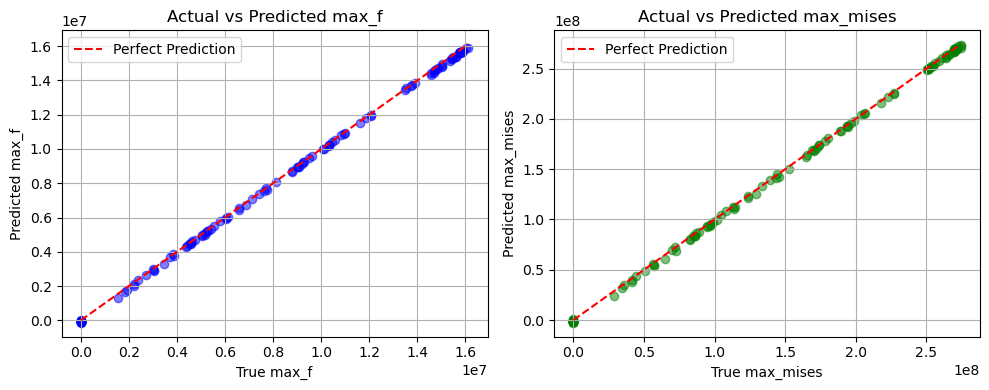

In [18]:
# Plot max_f
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(Y_true_flat[:, 0], Y_pred_flat[:, 0], alpha=0.5, c="blue")
plt.plot(
    [Y_true_flat[:, 0].min(), Y_true_flat[:, 0].max()],
    [Y_true_flat[:, 0].min(), Y_true_flat[:, 0].max()],
    "r--",
    label="Perfect Prediction",
)
plt.xlabel("True max_f")
plt.ylabel("Predicted max_f")
plt.title("Actual vs Predicted max_f")
plt.legend()
plt.grid(True)

# Plot max_mises
plt.subplot(1, 2, 2)
plt.scatter(Y_true_flat[:, 1], Y_pred_flat[:, 1], alpha=0.5, c="green")
plt.plot(
    [Y_true_flat[:, 1].min(), Y_true_flat[:, 1].max()],
    [Y_true_flat[:, 1].min(), Y_true_flat[:, 1].max()],
    "r--",
    label="Perfect Prediction",
)
plt.xlabel("True max_mises")
plt.ylabel("Predicted max_mises")
plt.title("Actual vs Predicted max_mises")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Create plots to visualize the first 5 actual vs predicted outputs for both `max_f` and `max_mises`.

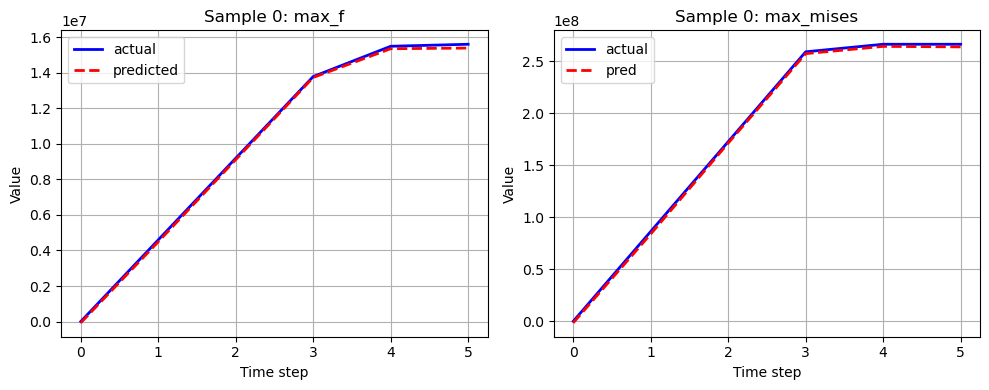

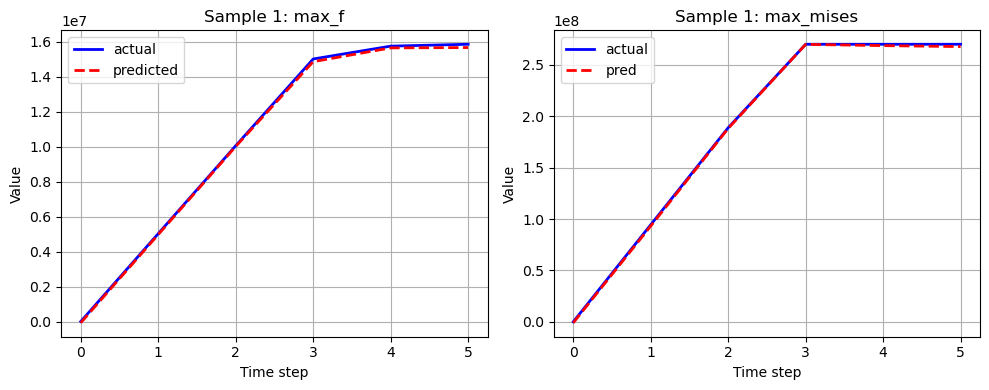

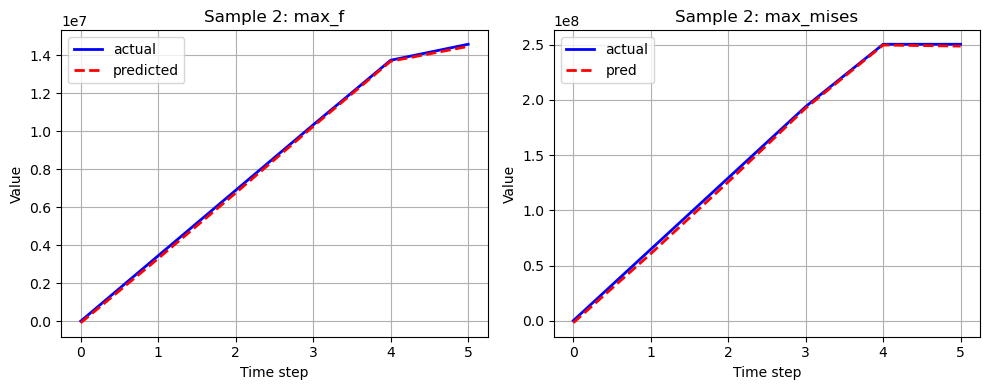

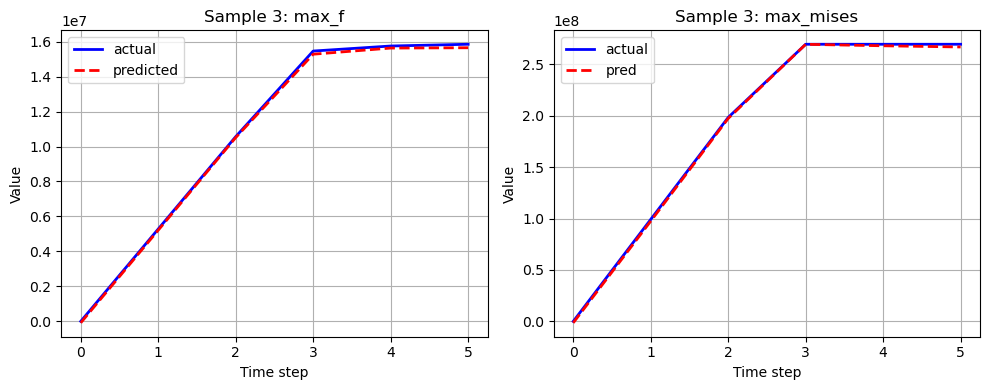

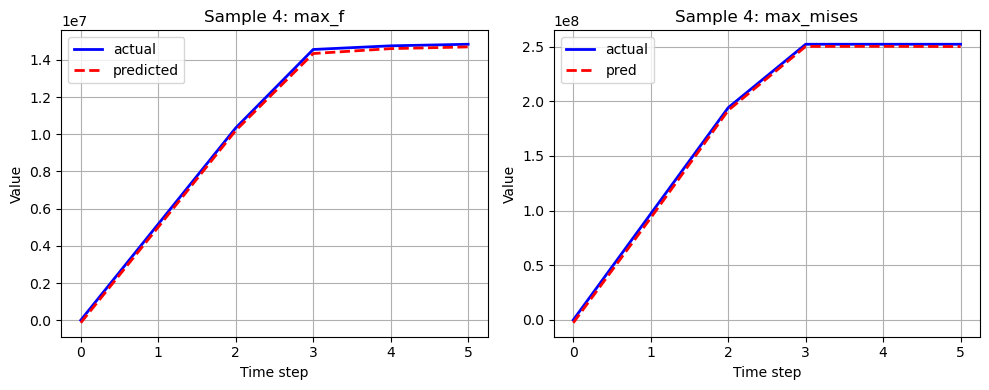

In [19]:
# Number of samples to plot
num_plot = 5
time_steps = Y_true.shape[1]  # 6

for i in range(num_plot):
    plt.figure(figsize=(10, 4))
    
    # FIXME Plot max_f
    plt.subplot(1, 2, 1)
    
    plt.plot(Y_true[i, :, 0], label="actual", color="blue", linewidth=2)
    plt.plot(Y_pred[i, :, 0], label="predicted", color="red", linestyle="--", linewidth=2)
    
    plt.title(f"Sample {i}: max_f")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)
    
    # FIXME Plot max_mises
    plt.subplot(1, 2, 2)

    plt.plot(Y_true[i, :, 1], label="actual", color="blue", linewidth=2)
    plt.plot(Y_pred[i, :, 1], label="pred", color="red", linestyle="--", linewidth=2)
    
    plt.title(f"Sample {i}: max_mises")
    plt.xlabel("Time step")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## 3.4 Boundary displacement to stress field

Predict the von-Mises stress field `Mises` from the displacements on the boundary `U_boundary`, Young's modulus `E`, and the tensile yield limit `sig0`.

**(a) Assemble the input and output features and tensors.**

For the prediction, the inputs and target features need to be assembled as tensors (`np.ndarrays`) of multiple samples. The first axis of these tensors corresponds to the sample axis.
Example for `U_boundary_tensor` (N=100, T=6, X=27, Y=27, F=2). You may need to expand scalar features to the spatiotemporal shape.

In [20]:
# Create empty list
#   Note: there are faster ways to do this, but we keep the code simple for clarity
E_list = []
sig0_list = []
U_boundary_list = []
Mises_list = []

# Iterate over the samples and extract the relevant data
for sample in samples_list:
    
    # FIXME Extract the relevant data from the sample
    U_boundary = sample["U_boundary"]
    Mises = sample["Mises"]
    E = sample["E"]
    sig0 = sample["sig0"]
    
    # FIXME Expand the scalars to match the structural shapes of the other features
    E = np.ones_like(Mises) * E
    sig0 = np.ones_like(Mises) * sig0
    
    U_boundary_list.append(U_boundary)
    Mises_list.append(Mises)
    E_list.append(E)
    sig0_list.append(sig0)

    
print("U_boundary ", U_boundary.shape)
print("Mises ", Mises.shape)
print("E ", E.shape)
print("sig0 ", sig0.shape)

U_boundary  (6, 27, 27, 2)
Mises  (6, 27, 27, 1)
E  (6, 27, 27, 1)
sig0  (6, 27, 27, 1)


Assemble the input and output tensors `X` and `Y` by concatenating the feature tensors along the last feature axis F (`np.concatenate`). 

In [21]:
# FIXME Convert the data to numpy array
U_boundary_tensor = np.asarray(U_boundary_list)  # (N, 6, 27, 27, 2)
E_tensor = np.asarray(E_list)  # (N, 6, 27, 27, 1)
sig0_tensor = np.asarray(sig0_list)  # (N, 6, 27, 27, 1)
Mises_tensor = np.asarray(Mises_list)  # (N, 6, 27, 27, 6)

# FIXME Assemble input features
X_2 = np.concatenate([U_boundary_tensor, E_tensor, sig0_tensor], axis=-1)

# FIXME Assemble target features:
Y_2 = np.concatenate([Mises_tensor], axis=-1)

print(X_2.shape)
print(Y_2.shape)

(100, 6, 27, 27, 4)
(100, 6, 27, 27, 1)


**(b) Split the dataset**

Perform a suitable dataset split for the size of the dataset you generated.
The sklearn function `train_test_split` may help you.

In [22]:
# FIXME Train-test split
X_2_train, X_2_test, Y_2_train, Y_2_test = train_test_split(
    X_2,
    Y_2,
    test_size=0.2,
    shuffle=True,
    random_state=42
)

**(c) Normalize the input and output data**

 Use the sklearn `StandardScaler` to scale inputs `X` and outputs `Y` to a standard deviation of +-1. 
 Ensure that the relative variance across the temporal axis T=6 (and later spatial axes X=Y=27) remain unchanged.
 Remember to restore the structural axes (T, X, Y) afterwards

 (Tip: use `np.reshape` to collapse all non-feature axes into the samples axis and restore the shape afterwards).

In [23]:
# FIXME Standardize and reshape the values

# Store the original structual shape: (N, T, X, Y, F)
X_2_train_shape = X_2_train.shape
X_2_test_shape = X_2_test.shape
Y_2_train_shape = Y_2_train.shape
Y_2_test_shape = Y_2_test.shape

# Flatten the non-features axes into one dimension: (N * T * X * Y, F)
X_2_train_flat = X_2_train.reshape(-1, X_2_train_shape[-1])
X_2_test_flat = X_2_test.reshape(-1, X_2_test_shape[-1])
Y_2_train_flat = Y_2_train.reshape(-1, Y_2_train_shape[-1])
Y_2_test_flat = Y_2_test.reshape(-1, Y_2_test_shape[-1])

# Fit the scaler into the dataset and transfor it
X_2_scaler = StandardScaler()
Y_2_scaler = StandardScaler()

X_2_train_scaled_flat = X_2_scaler.fit_transform(X_2_train_flat)
X_2_test_scaled_flat = X_2_scaler.transform(X_2_test_flat)
Y_2_train_scaled_flat = Y_2_scaler.fit_transform(Y_2_train_flat)
Y_2_test_scaled_flat = Y_2_scaler.transform(Y_2_test_flat)

# Restore to the original structural shape: (N, T, X, Y, F)
X_2_train0 = X_2_train_scaled_flat.reshape(X_2_train_shape)
X_2_test0 = X_2_test_scaled_flat.reshape(X_2_test_shape)
Y_2_train0 = Y_2_train_scaled_flat.reshape(Y_2_train_shape)
Y_2_test0 = Y_2_test_scaled_flat.reshape(Y_2_test_shape)

print("X_2_train ", X_2_train_shape)
print("X_2_test ", X_2_test_shape)
print("Y_2_train ", Y_2_train_shape)
print("Y_2_test ", Y_2_test_shape)
print("X_2_train0 ", X_2_train0.shape)
print("X_2_test0 ", X_2_test0.shape)
print("Y_2_train0 ", Y_2_train0.shape)
print("Y_2_test0 ", X_2_test0.shape)

X_2_train  (80, 6, 27, 27, 4)
X_2_test  (20, 6, 27, 27, 4)
Y_2_train  (80, 6, 27, 27, 1)
Y_2_test  (20, 6, 27, 27, 1)
X_2_train0  (80, 6, 27, 27, 4)
X_2_test0  (20, 6, 27, 27, 4)
Y_2_train0  (80, 6, 27, 27, 1)
Y_2_test0  (20, 6, 27, 27, 4)


**(d) Model development**

Develop a neural network model. Either use `tf.keras.Model` or `tf.keras.Sequential`.

To define the architecture in the model, tensorflow's `layers` module may help you (e.g., `layers.Conv2D`, `layers.MaxPool2D`, `layers.AveragePoling2D`).
Chose reasonable activation functions for your machine-learning problem.
You will need to operate on individual time steps. For layers to be applied to individual frames of a time step, wrap them in a `layers.TimeDistributed` layer.

Compile the model and select an apropriate optimzer, loss, and metric function.

In [24]:
# FIXME Develop a TimeDistributed CNN model

# Extract shape from normalized inputs
input_shape_2 = X_2_train0.shape[1:]

model = models.Sequential([
    # Input layer
    layers.Input(shape=input_shape_2),

    # 1st Conv Layer: Extracts low-level spatial features
    layers.TimeDistributed(layers.Conv2D(filters=128, kernel_size=(5, 5), padding="same", activation="relu")),

    # 2nd Conv Layer: Extracts deeper feature representations
    layers.TimeDistributed(layers.Conv2D(filters=256, kernel_size=(5, 5), padding="same", activation="relu")),


    # 2nd Conv Layer: Extracts deeper feature representations
    layers.TimeDistributed(layers.Conv2D(filters=256, kernel_size=(5, 5), padding="same", activation="relu")),

    
    # 2nd Conv Layer: Extracts deeper feature representations
    layers.TimeDistributed(layers.Conv2D(filters=256, kernel_size=(5, 5), padding="same", activation="relu")),

    # 2nd Conv Layer: Extracts deeper feature representations
    layers.TimeDistributed(layers.Conv2D(filters=256, kernel_size=(5, 5), padding="same", activation="relu")),

    # 3rd Conv Layer: Bottleneck feature refinement
    layers.TimeDistributed(layers.Conv2D(filters=128, kernel_size=(5, 5), padding="same", activation="relu")),

    # Output Conv Layer: Maps back to 1 output channel (von Mises Stress Field)
    # Using "linear" activation because stress outputs are continuous scalar values
    layers.TimeDistributed(layers.Conv2D(filters=Y_2_train0.shape[-1], kernel_size=(3, 3), padding="same", activation="linear"))
])
                           
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.5*1e-4),
    loss = "mse",
    metrics = ["mae"]
)

In [25]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_5              │ (None, 6, 27, 27, 128) │        12,928 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 6, 27, 27, 256) │       819,456 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 6, 27, 27, 256) │     1,638,656 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 6, 27, 27, 256) │     1,638,656 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 6, 27, 27, 256) │     1,638,656 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_10             │ (None, 6, 27, 27, 128) │       819,328 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_11             │ (None, 6, 27, 27, 1)   │         1,153 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,568,833 (25.06 MB)

 Trainable params: 6,568,833 (25.06 MB)

 Non-trainable params: 0 (0.00 B)

**(e) Train the Model**

Train the model until you achieve convergence and generalization. Remember to validate your training performance against a validation dataset.

In the process, you may need to change your model hyperparameters (number of layers, number of units per layer, activation functions, learning rate, batch size, ...).

Do not evaluate your test set yet!

In [26]:
# Fixme: Train
history = model.fit(
    X_2_train0,
    Y_2_train0,
    validation_split=0.2,
    epochs = 200,
    batch_size = 5,
    verbose = 1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 513ms/step - loss: 0.8613 - mae: 0.7702 - val_loss: 0.7079 - val_mae: 0.6748
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 479ms/step - loss: 0.5527 - mae: 0.5881 - val_loss: 0.5251 - val_mae: 0.5894
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 487ms/step - loss: 0.4190 - mae: 0.5022 - val_loss: 0.4447 - val_mae: 0.5401
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 486ms/step - loss: 0.3521 - mae: 0.4588 - val_loss: 0.3502 - val_mae: 0.4571
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 479ms/step - loss: 0.2884 - mae: 0.4062 - val_loss: 0.4311 - val_mae: 0.5054
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 465ms/step - loss: 0.2981 - mae: 0.4243 - val_loss: 0.2925 - val_mae: 0.4322
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 479ms/step - loss: 0.2208 - mae: 0.3556 - val_loss: 0.2215 - val_mae: 0.3621
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 493ms/step - loss: 0.1644 - mae: 0.3028 - val_loss: 0.1705 - val_mae: 0.3103
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 453ms/

**(f) Plot the training and validation performance**

Plot your loss and metrics using `subplot` from `matplotlib`

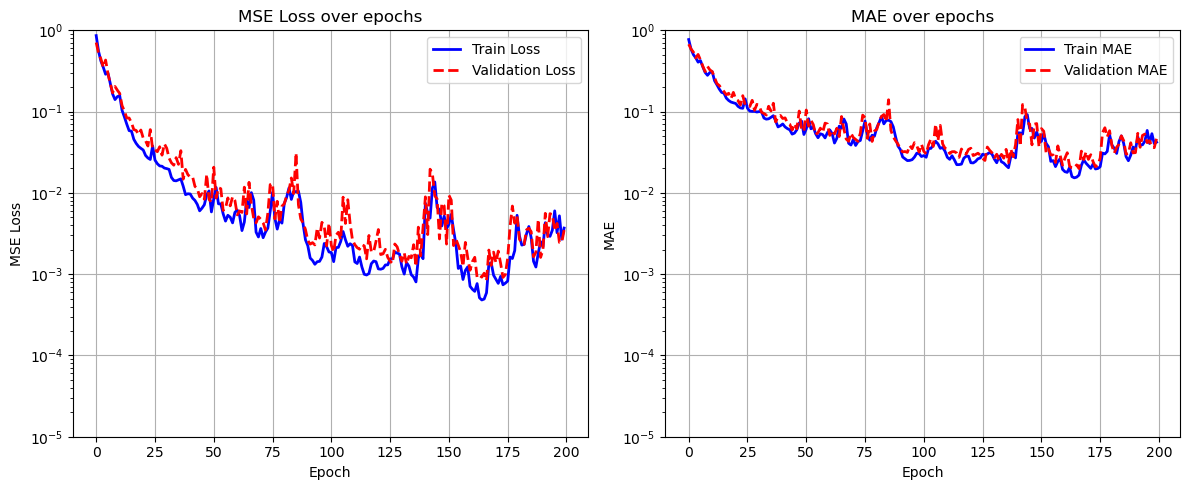

In [32]:
# FIXME Plot training & validation loss and MAE
plt.figure(figsize=(12, 5))

# FIXME Plot Loss
plt.subplot(1, 2, 1)

if "loss" in history.history:
    plt.plot(history.history["loss"], label="Train Loss", color="blue", linewidth=2)
    plt.plot(history.history["val_loss"], label="Validation Loss", color="red", linestyle="--", linewidth=2)

plt.title('MSE Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.yscale("log") # Log scale makes convergence and small difference clear
plt.ylim(1e-5, 1.0)
plt.grid(True)

# FIXME Plot metric
if "mae" in history.history:
    plt.subplot(1, 2, 2)

    plt.plot(history.history["mae"], label="Train MAE", color="blue", linewidth=2)
    plt.plot(history.history["val_mae"], label="Validation MAE", color="red", linestyle="--", linewidth=2)
    
    plt.title('MAE over epochs')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.yscale("log") # Log scale makes convergence and small difference clear
    plt.ylim(1e-5, 1.0)
    plt.grid(True)

plt.tight_layout()
plt.show()

**(g) Postprocess the outputs on the test set**

Retransform the predicted data to it's original scale using `inverse_transform`. Also, make sure to use `reshape` so that the final shape is correct.

In [33]:
# Predict
Y_2_pred0 = model.predict(X_2_test0)

# Store original shape: (N, T, X, Y, F)
Y_2_pred0_shape = Y_2_pred0.shape

# Reshape to 2D for inverse transformation:(N * T * X * Y, F)
Y_2_pred0_flat = Y_2_pred0.reshape(-1, Y_2_pred0_shape[-1])
Y_2_test0_flat = Y_2_test0.reshape(-1, Y_2_test_shape[-1])

# Inverse transfor back to original physical scale
Y_2_pred0_ori_flat = Y_2_scaler.inverse_transform(Y_2_pred0_flat)
Y_2_test0_ori_flat = Y_2_scaler.inverse_transform(Y_2_test0_flat)

# Reshape back to the original shape: (N, T, X, Y, F)
Y_2_pred = Y_2_pred0_ori_flat.reshape(Y_2_pred0_shape)
Y_2_true = Y_2_test0_ori_flat.reshape(Y_2_test_shape)

print("Y_2_pred0:", Y_2_pred0.shape)
print("Y_2_pred:", Y_2_pred.shape)
print("Y_2_true:", Y_2_true.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step
Y_2_pred0: (20, 6, 27, 27, 1)
Y_2_pred: (20, 6, 27, 27, 1)
Y_2_true: (20, 6, 27, 27, 1)


**(h) Evaluate the model predictions on the test set**

Evaluate the predicitons against the targets using `mean_absolute_error`, `mean_squared_error`, `r2_score`.

In [34]:
# FIXME Flatten spatial and time dims to compute metrics over all pixels and frames
Y_2_true_flat = Y_2_true.reshape(-1, Y_2_test_shape[-1]) 
Y_2_pred_flat = Y_2_pred.reshape(-1, Y_2_pred0_shape[-1])

print(Y_2_true_flat.shape)

# FIXME Compute overall metrics:
mae_overall = mean_absolute_error(Y_2_true_flat[:, 0], Y_2_pred_flat[:, 0])
rmse_overall = mean_squared_error(Y_2_true_flat[:, 0], Y_2_pred_flat[:, 0])
r2_overall = r2_score(Y_2_true_flat[:, 0], Y_2_pred_flat[:, 0])
print(f"\nOverall metrics: MAE={mae_overall:.4f}, RMSE={rmse_overall:.4f}, R2={r2_overall:.4f}")

(87480, 1)

Overall metrics: MAE=4542861.8672, RMSE=29434253367995.5938, R2=0.9957


Plot residual plots of actual vs predicted values for each of the output features.

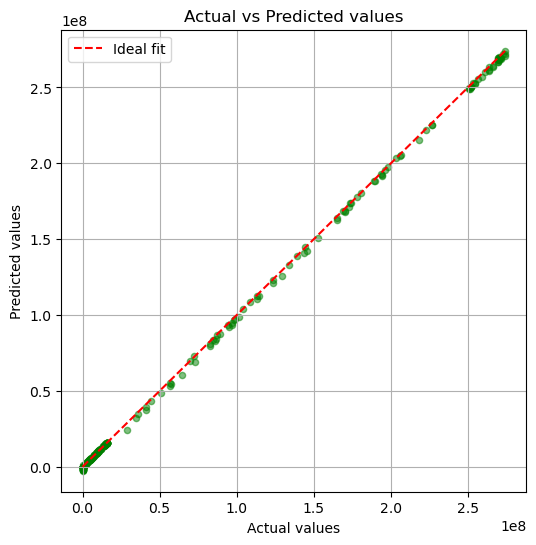

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(Y_true_flat, Y_pred_flat, alpha=0.5, s=20, c="green")
plt.plot([Y_true_flat.min(), Y_true_flat.max()], [Y_true_flat.min(), Y_true_flat.max()], 'r--', label='Ideal fit')
plt.xlabel('Actual values')
plt.ylabel('Predicted values')
plt.title('Actual vs Predicted values')
plt.legend()
plt.grid(True)
plt.show()

Create a plot to visualize the first 5 actual sample vs predicted for the last timeframe.

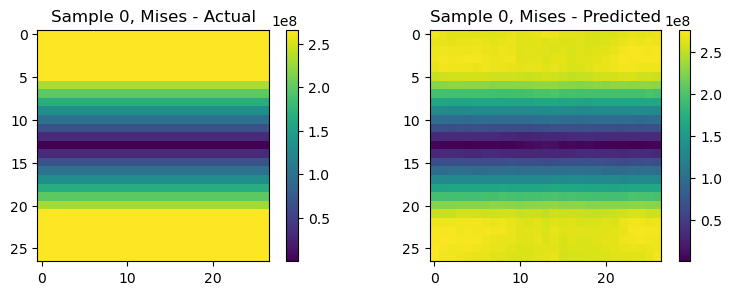

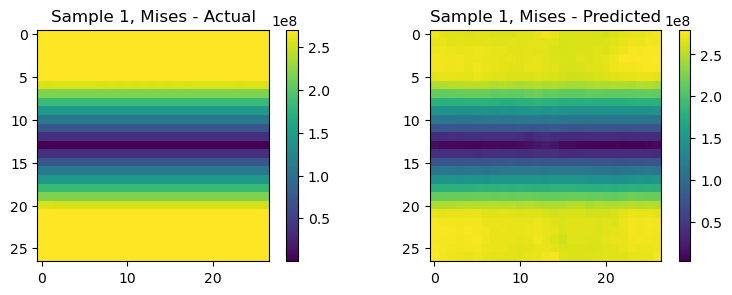

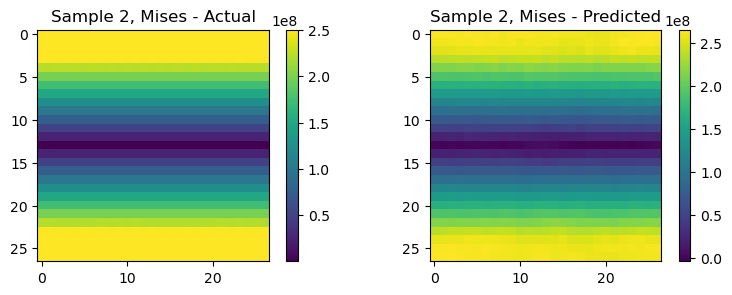

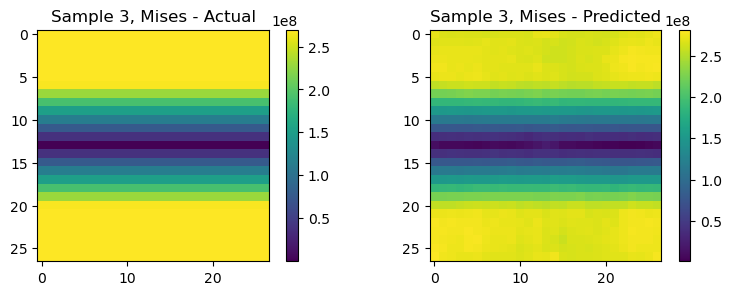

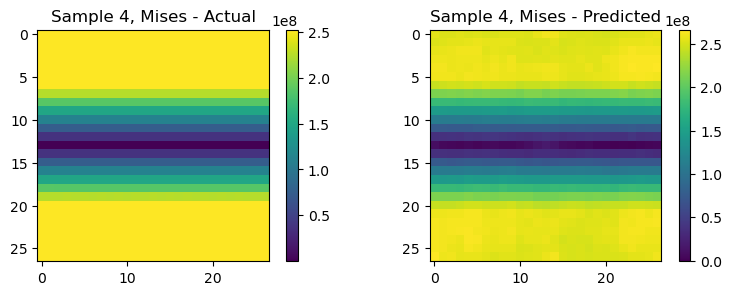

In [36]:
num_samples = 5
time_index = -1  # pick time step 0 for visualization

for sample_idx in range(num_samples):
    plt.figure(figsize=(8, 3))

    # FIXME Actual
    actual_field = Y_2_true[sample_idx, time_index, :, :, 0]
    plt.subplot(1, 2, 1)
    plt.imshow(actual_field.T, cmap='viridis')
    plt.colorbar()
    plt.title(f'Sample {sample_idx}, Mises - Actual')

    # FIXME Predicted
    predicted_field = Y_2_pred[sample_idx, time_index, :, :, 0]
    plt.subplot(1, 2, 2)
    plt.imshow(predicted_field.T, cmap='viridis')
    plt.colorbar()
    plt.title(f'Sample {sample_idx}, Mises - Predicted')

    plt.tight_layout()
    plt.show()